# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Emma Pereira

**ID**: ejp99

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\emmaj\OneDrive\Desktop\4750HW\bee4750-hw1-ejp99`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [2]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [3]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [4]:
function minimum(array)
    # initialize the minimum value counter
    min_value = 0
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 0


In [5]:
#Fixed Code

function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

#### Write Up Problem 1.1

The issue with the code is that the minimum value was set to 0, so when it was being compared to the other numbers, it would not change because every number is higher than 0. And therefore, the return value was 0 and the numbers were never compared to eachother. To fix this, in my code I changed the line that sets the initial minimum value to the first value in the inputed array, which allowed for the for loop to compare the first value with every value, and change the compared value if the value was less. This, in turn, corrected the fucntion to return the minimum value of the inputed array.
#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [6]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(student_grades)
  return average_grade
end

@show average_grade;

UndefVarError: UndefVarError: `average_grade` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [7]:
#Fixed code
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(grades)
  return average_grade
end

@show class_average(student_grades);

class_average(student_grades) = 94.4


What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Write Up Problem 1.2

The "UndefVarError" means that a variable that was called in a function was never defined previously. This happens in the code twice, firstly in the function "class_average" because although "student_grades" was defined before the function, it does not exist in teh scope of the function and therefore will be undefined. This was fixed by changing the variable called in the function to "grades". Secondly, it happens in the final line because "average_grade" was only defined in the scope of the function but not outside of it. This was fixed by changing the line to "class_average(student_grades)", as this instead calls the function with the desired input of the students' grades.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [8]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zero(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

MethodError: MethodError: no method matching setindex!(::Int64, ::Bool, ::Int64)
The function `setindex!` exists, but no method is defined for this combination of argument types.

In [9]:
#Fixed code
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1000
outcomes = []
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    push!(outcomes,(sum(passadieci()) > 11))
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.382


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Write Up Problem 1.3

The "MethodError" here indicates that a setIndex! operations was attempted to be used on an incompatible class type. In this case, the integer variable "outcomes" was attempted to be changed in the line "outcomes[i] = (sum(passadieci()) > 11)", where the input of a value did not work because the variable "outcomes" was not a list and could therefore not be appended. This was fixed by changing the variable to an empty list and using the push! function to append the true and false statements to the empty "outcomes" list. The final line that was counting the number of wins worked, as the wins equalled "true", or one, and the losses equalled "false", or 0.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [11]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect - m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

MethodError: MethodError: no method matching -(::Vector{Float64}, ::Float64)
For element-wise subtraction, use broadcasting with dot syntax: array .- scalar
The function `-` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  -(!Matched::Complex{Bool}, ::Real)
   @ Base complex.jl:329
  -(!Matched::BigFloat, ::Union{Float16, Float32, Float64})
   @ Base mpfr.jl:565
  -(!Matched::Missing, ::Number)
   @ Base missing.jl:123
  ...


In [10]:
#Fixed code
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [-0.32138361574759955, -0.04829639007274644, 0.4551983087456717, -0.4863253978184334, 0.04781502871566379, 0.13110797754480785, 0.3093963906656687, 0.06032273784865172, -0.4035906760789608, -0.4100114151694405, -0.15022163840488711, -0.026363403835549026, 0.23454011235819738, 0.3709477946085967, 0.2666005350420556, 0.312996362141285, -0.4194648750631669, -0.15302139734308273, -0.4516131412987534, 0.15870247220431255, -0.32973800699855293, 0.43818768368800254, -0.25209812429686596, -0.2815571383550006, 0.30348044859950873, 0.27086016075172115, 0.4357505556768305, 0.1234813649270603, 0.18873459283431748, 0.18090949069498663, -0.14693692699195804, 0.464543807894621, -0.24967082359478787, 0.21832029137518405, 0.45493182730454695, -0.34242462124213857, 0.18641555621824235, 0.41785103821065706, 0.28540493054860683, -0.03102244344384575, 0.13894668958368084, 0.3854143812992108, -0.25998457835670274, 0.20471090486054455, -0.2858677869959565, -0.2106597538734155, 0.24

1000-element Vector{Float64}:
 -0.32138361574759955
 -0.04829639007274644
  0.4551983087456717
 -0.4863253978184334
  0.04781502871566379
  0.13110797754480785
  0.3093963906656687
  0.06032273784865172
 -0.4035906760789608
 -0.4100114151694405
  ⋮
 -0.33183369688448383
  0.23345922864436663
  0.05786685133075009
  0.11021773915954358
 -0.16873520851932922
 -0.09463664829798712
  0.13852422804262077
  0.006152010220246806
  0.15641725004099205

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Write Up Probem 1.4

This "MethodError" referred to the issue of differing types of values being unable to perform an operation. This happens in the "return vect - m" line, where a scalar and a vector value were attempted to be subtracted from one another. This was fixed by adding a "." before the subtraction operation, allowing for broadcasting to ensure each value in teh opration is of the same size.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

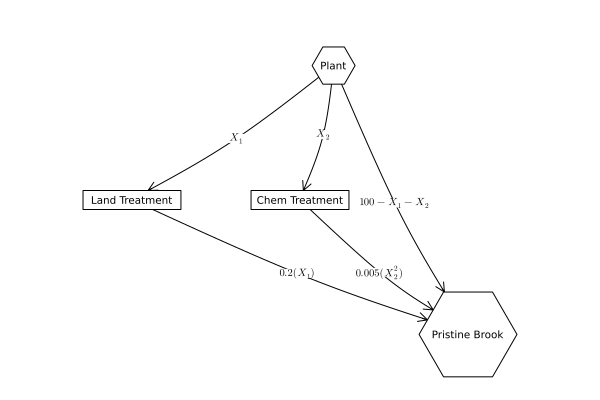

In [12]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"X_1", (1,3) => L"X_2", (1, 4) => L"100-X_1-X_2",(2, 4) => L"0.2(X_1)",(3, 4) => L"0.005(X_2^2)")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

#### Problem 2.1 Write Up

The following is the mathematical model for the treatment cost and the amount of YUK discharged:

\begin{alignat}{2}
f_1(X_1, X_2) = 100 + 0.005X_2^2 - X_1 - X_2 + 0.2X_1\\
f_2(X_1, X_2) = \frac{X_1^2}{20} + 1.5X_2
\end{alignat}

Where the first equation represents the total YUK discharged into Pristine Brook and the second equation represents the total cost of the treatment. In terms of constraints for the system, one is that X_1 and X_2 must be positive, as we cannot have negative concentrations, and their sum must be less than or equal to 100, as to not exceed the original input of 100 m^3/day or wastewater

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [13]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [14]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


In [15]:
#Finished Code
#Create function
function YUK_y_cost(X1, X2)
    #yuk discharge equation
    yuk = 100 + (0.005 * X2^2) - X1 - X2 + (0.2*X1)
    #cost equations
    cost = ((X1^2)/20) + (1.5*X2)
    #return both values as a tuple
    return (yuk, cost)
end

#example of singular input
println("Exmaple of singular input: ")
@show YUK_y_cost(2, 5)

#demonstrate ability to input an array of values
#set example array inputs
yuk1 = [1, 2, 3, 4, 5]
cost1 = [5, 6, 7, 8, 9]

#broadcast function
output = YUK_y_cost.(yuk1, cost1)
a = [out[1] for out in output]
b = [out[2] for out in output]

println("Example of array of inputs: ")
@show a;
@show b;

Exmaple of singular input: 
YUK_y_cost(2, 5) = (93.525, 7.7)
Example of array of inputs: 
a = [94.325, 92.58000000000001, 90.845, 89.11999999999999, 87.405]
b = [7.55, 9.2, 10.95, 12.8, 14.75]


Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.2 Write Up

Firstly, I defined a function that took X1 and X2 (the YUK discharge as input to the land and chemical treatments in the diagram) to insert as variables defined in my mathematical model. In the function, I added each equation, so the answers would output the answers for the YUK discharge and total cost of treatment. This worked for singular inputs, but to input an array of inputs I broadcasted the function for a set of variables that were equal length arrays, and outputed the array of values corresponding to the arrays I inputed.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

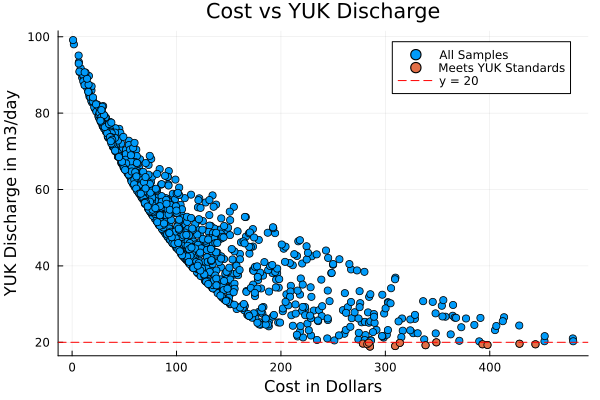

In [16]:
#Finished code
#alpha is three flows, therefore three vectors
alpha = [1, 1, 1]
dirk = Dirichlet(alpha)
d = rand(dirk, 1000)*100
ded = transpose(d)

x1 = []
x2 = []

for i in 1:1000
    push!(x1, ded[i, 1])
    push!(x2, ded[i, 2])
end

output = YUK_y_cost.(x1, x2)
yuk = [out[1] for out in output]
cost = [out[2] for out in output]

yukstan = []
coststan = []

for i in 1:1000
    if yuk[i] <= 20
        push!(yukstan, yuk[i])
        push!(coststan, cost[i])
    end
end

scatter(cost, yuk, title = "Cost vs YUK Discharge", label = "All Samples")
scatter!(coststan, yukstan, linecolor = :red, label = "Meets YUK Standards")
hline!([20], linestyle = :dash, linecolor = :red, label = "y = 20")
xlabel!("Cost in Dollars")
ylabel!("YUK Discharge in m3/day")

#### Problem 2.3 Write Up

For my code, I first set up the 2 parameters of the Dirichiret distribution and made 1000 random values of it. As I wanted X1 and X2 to add up to 100, I multiplied the random values made by the distribution by 100. I also transposed the matrix for ease of looping. After this, I looped through all of the random numbers and appended them to two separate lists to represent X1 and X2. These arrays were inputed into my previous function to solve for YUK discharge and cost of treatment, which was then plotted on a graph as blue points. To show the values that met effluent standards, I looped through the solved YUK discharge and cost values and appended any set of points where the discharge was less than or equal to 20, and plotted them as red dots on the same graph.

From looking at the graph, there are values that meet effluenct standards with varying costs from around $250-$400. Overall, we can see in the graph that there was a steep tradeoff between YUK discharge and treatment cost, where the closer the YUK discharge was to meeting the effluent standards there was a exponential increase in cost. As the treatment costs increase exponetially with YUK discharge, perhaps changes must be made at the Cheap Plastics company to overall decrease their wastewater output.

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

#### Problem 2.4 Write Up

Optimized Price -->  $240 when effluent is 20 kg/day
###
This was found by referring to the model equations from problem 2.1, while also considering the constraint equation 100 = X1 + X2. When optimizing pricce, this was assumed to mean meeting effluent standards exactly, which meant setting f1 equal to 20. Using the constraint, f1 was put in terms of X2, and values for X2 were solved for. This was repeated for putting f1 in terms of X1. With these two solutions, they were subbed back into the constraint equation to get their respective other effluent value. These values turned out to be (100, 0) and (60,40), using the format (X1, X2). To determine which of these values was teh most cost efficient, they were subbed into f2, which outputted $500 and $350 for (100, 0) and (60,40), respectively. As $350 < $500, the (100,0) answer was rejected and the final answer was found to be X1 = 60 and X2 = 40.
###
Optimized Effuent --> $350 when effluent is 18 kg/day
###
As we are optimizing effluent, we assumed that there is no effluent planned to go from the Cheap Plastics Company to Pristine Brook. Therefore, f1 was modified to be 0.2X1 + 0.005X2^2 = 20. The constraint equation was once again used to put this equation only in terms of X2, leading to the final equation being -0.2X2 + 0.005x2^2 - 20 = 0. It was determined that minimizing effluent would mean finding the extremes of teh derivative of the effluent equation, and therefore the derivative with respect to YUK was found analytically to be -0.2 + 0.01X2. This equation was set equal to 0, and X2 was found to be 20, and using the cnstaint equation X1 was 80. These values were plugged into the original eflfuent equation (f1), leading to a total effluent output to be 18 kg/day. And finally, ,plugging these X1 and X2 values into f2 led to the required cost of this effluent iutput to be $350

## References

List any external references consulted, including classmates.

I worked with Pranati Patnam for a good portion of this assignment, so therefore there may be similar code concepts between us.